In [301]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

In [302]:
sales=pd.read_csv('sales data-set.csv')
features=pd.read_csv('Features data set.csv')
stores=pd.read_csv('stores data-set.csv')

In [303]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [304]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [305]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [306]:
sales.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [307]:
stores.isna().sum()

Store    0
Type     0
Size     0
dtype: int64

In [308]:
features.isna().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [309]:
features. CPI. fillna(method='ffill', inplace=True)
features. Unemployment. fillna(method='ffill', inplace=True)
features.drop(['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], axis=1, inplace=True)
features. isna().sum()

Store           0
Date            0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64

In [310]:
sales.duplicated().sum()

np.int64(0)

In [311]:
stores.duplicated().sum()

np.int64(0)

In [312]:
features.duplicated().sum()

np.int64(0)

In [313]:
feature_sales = pd.merge(features, sales, how="left", on=["Store", "Date", "IsHoliday"])
feature_sales.shape

(423325, 9)

In [314]:
sales_index = pd.merge(feature_sales, stores, how="left", on=["Store"])
sales_index.shape

(423325, 11)

In [315]:
sales_index.drop(['Type'], axis=1, inplace=True)

In [316]:
print(sales_index.columns)

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'IsHoliday', 'Dept', 'Weekly_Sales', 'Size'],
      dtype='object')


In [317]:
sales_index['Date'] = pd.to_datetime(sales_index['Date'], dayfirst=True)
sales_index = sales_index[sales_index['Date'] <= '2012-10-26']

In [318]:
sales_index.Date = pd.to_datetime(sales_index.Date, dayfirst=True)
grouped = sales_index.groupby('Date').sum().reset_index()
grouped. sort_values(by='Date', ascending= True, inplace=True)
grouped.set_index("Date", inplace=True) #set 'Date' column as index
grouped

,Store,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Size
Date,,,,,,,,,
2010-02-05,65124,98336.32,8031.304,494662.287628,25344.240,0,130557.0,49750740.50,406107232
2010-02-12,65082,98617.51,7969.678,494787.511155,25324.966,2956,131179.0,48336677.63,406812940
2010-02-19,65610,110263.05,7959.505,498168.102706,25531.797,0,131897.0,48276993.78,408678503
2010-02-26,65045,113995.84,7925.330,494856.196950,25264.617,0,130161.0,43968571.13,405309063
2010-03-05,64897,124749.05,8042.466,493789.321202,25237.995,0,129670.0,46871470.30,405026220
...,...,...,...,...,...,...,...,...,...
2012-09-28,65866,201865.51,11428.121,521073.972005,21402.982,0,130785.0,43734899.40,402858901
2012-10-05,66296,194799.47,11452.944,523770.802422,20659.811,0,132468.0,47566639.31,405732233
2012-10-12,66453,172484.98,11653.301,526610.121540,20788.519,0,133371.0,46128514.25,407324080


In [319]:
# Ensure 'Date' is datetime (you already did this)
sales_index['Date'] = pd.to_datetime(sales_index['Date'], dayfirst=True)

# Set 'Date' as index
sales_index = sales_index.set_index('Date')

# Now resample by week
weekly_sales = sales_index.resample('W').sum()

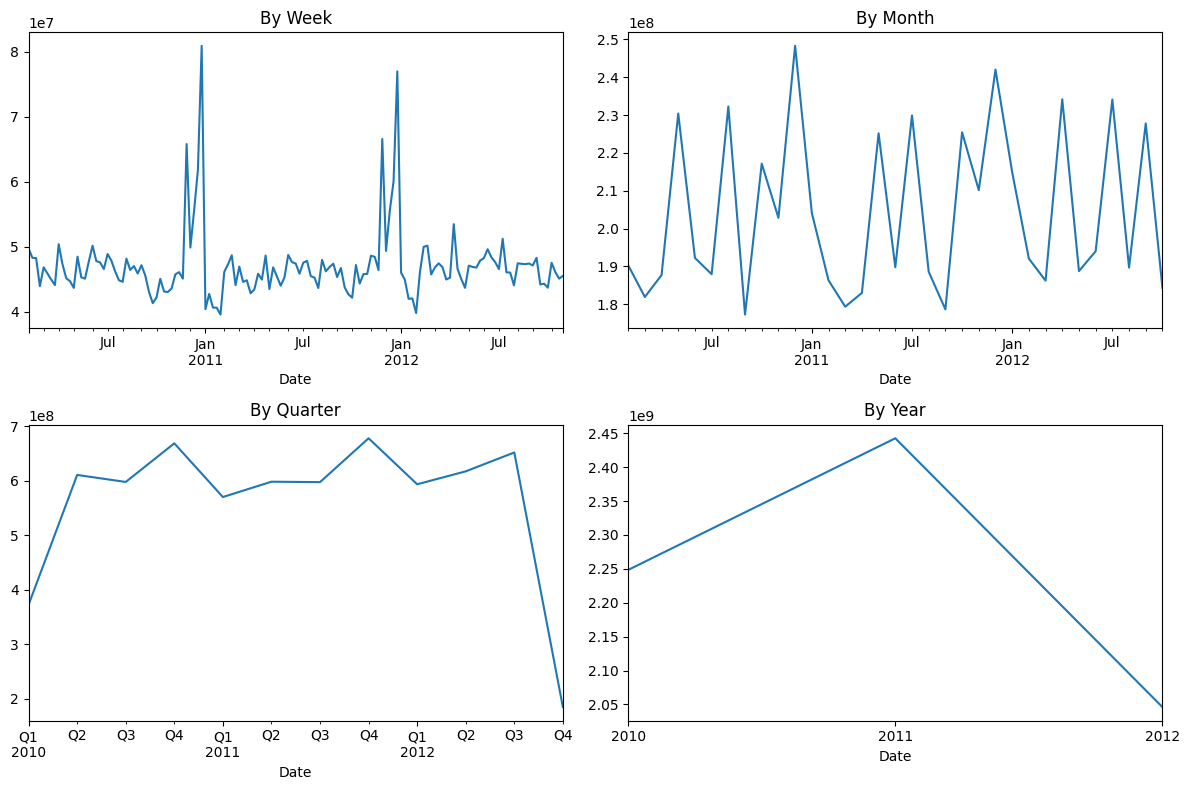

In [320]:
#aggregating the data over longer periods to help us observe trends

fig, ax = plt.subplots(ncols=2,nrows=2,figsize=(12,8))
weekly_sales.Weekly_Sales.resample('w').sum().plot(ax=ax[0,0]) # group by week
weekly_sales.Weekly_Sales.resample('m').sum().plot(ax=ax[0,1]) # group by month
weekly_sales.Weekly_Sales.resample('q').sum().plot(ax=ax[1,0]) # group by quarter
weekly_sales.Weekly_Sales.resample('a').sum().plot(ax=ax[1,1]) # group by year
ax[0,0].set_title('By Week')
ax[0,1].set_title('By Month')
ax[1,0].set_title('By Quarter')
ax[1,1].set_title('By Year')
fig.tight_layout()
plt.show()

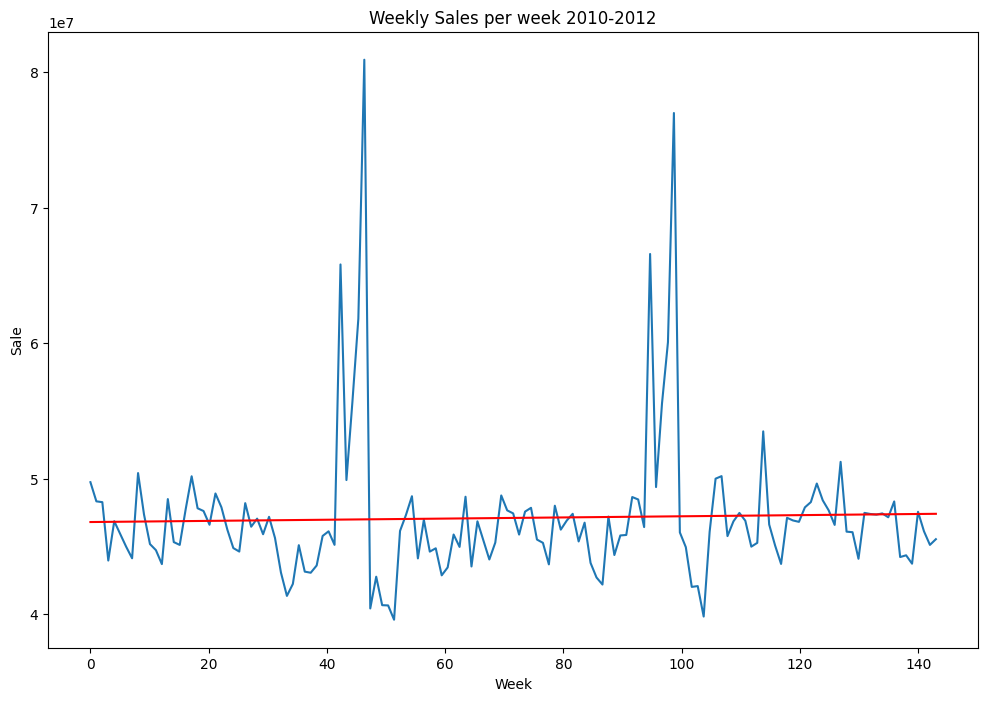

In [321]:
data_points=np.linspace(0,len(weekly_sales),num=len(weekly_sales)) # Creates list of data points as long as dataframe

line_coef = np.polyfit(data_points,weekly_sales.Weekly_Sales,1) # Finds the trendline of the weekly sales data

polynomial = np.poly1d(line_coef) # Function that for any independent variable given, will return the dependent variable

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(data_points,weekly_sales.Weekly_Sales)
ax.plot(data_points, polynomial(data_points),c='red')
ax.set_title('Weekly Sales per week 2010-2012')
ax.set_ylabel('Sale')
ax.set_xlabel('Week')
plt.show()

In [322]:
from statsmodels.tsa.stattools import adfuller

#Null Hypothesis- The data is not stationary
#Alternate Hypothesis- The data is stationary

result = adfuller(weekly_sales.Weekly_Sales)
print('p-value: ' +str(result[1]))

#The p-value is less than 0.05, so the null hypothesis can be rejected and conclude the data is stationary.

p-value: 2.675979158986027e-07


<Figure size 640x480 with 0 Axes>

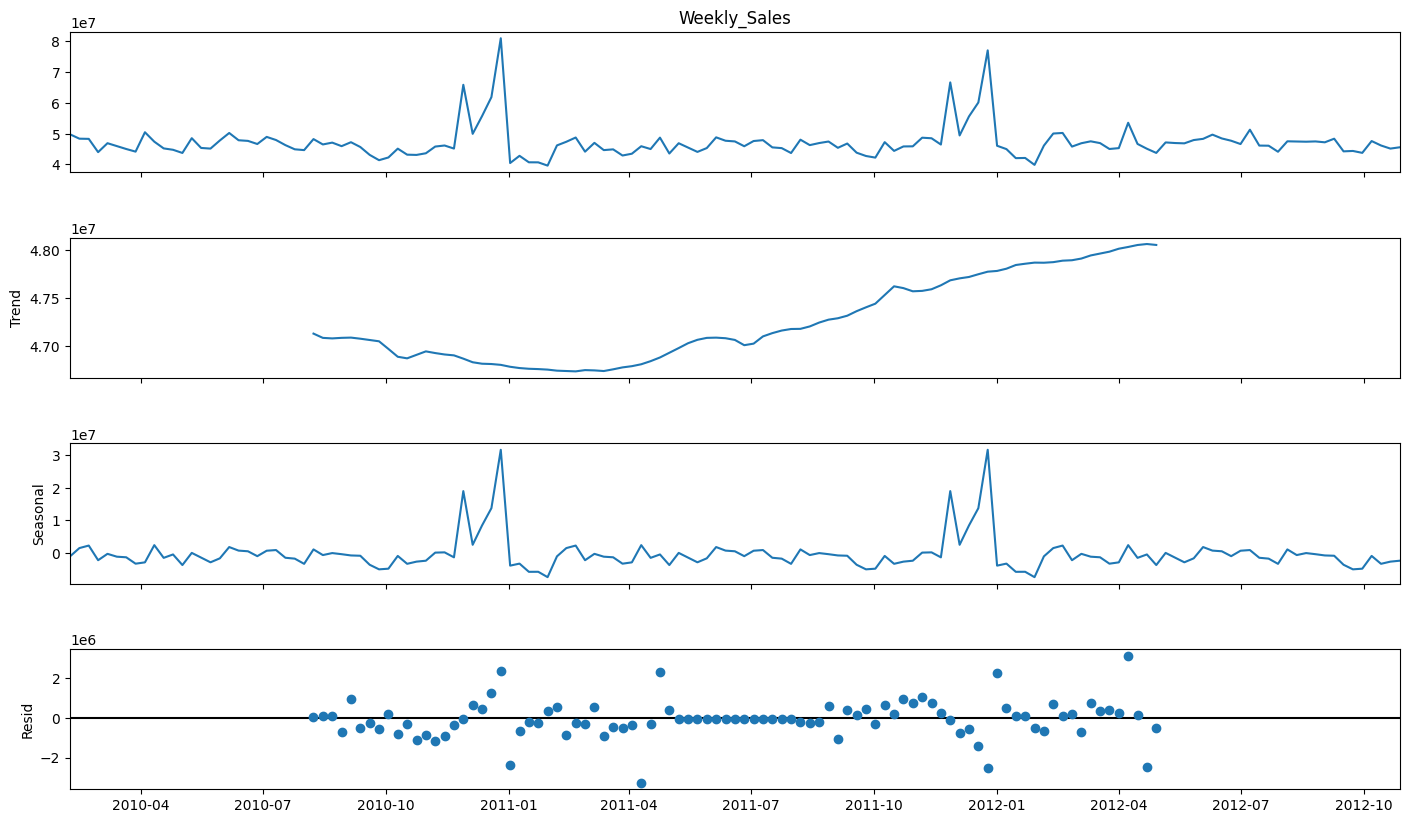

In [323]:
from statsmodels.tsa.seasonal import seasonal_decompose

#This function takes time series data and breaks it down into different parts, these parts being:

#Observed- The time series data as observed
#Trend- The observed trend within the data
#Seasonal- The observed seasonality within the data
#Residual- What is left once the trend and seasonality has been removed

decompose = seasonal_decompose(weekly_sales.resample('w').sum().Weekly_Sales, period=52)  

fig = plt.figure()  
fig = decompose.plot() 
fig.set_size_inches((16, 9))
plt.show()

<Axes: xlabel='Date'>

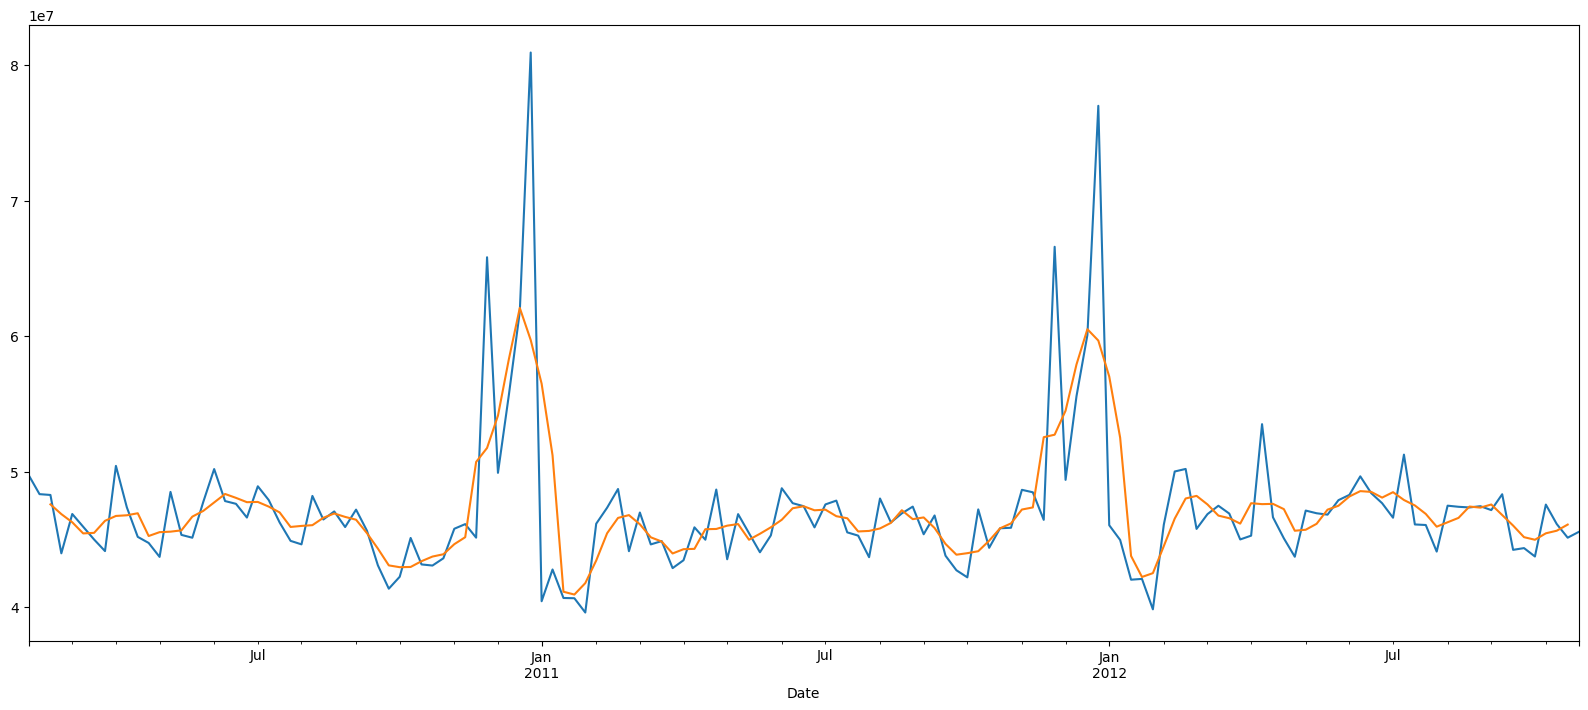

In [324]:
#Rolling values allow us to see how the data is behaving through moving windows, 
#and can be far more informative than looking at the raw data. 
#Looking at each data point individually is risky, as this allows for daily 
#anomalies to have a large effect. Instead, by grouping dates together we can 
#more easily ignore outliers and see what the overall trend is.

fig, ax = plt.subplots(figsize=(20,8))
weekly_sales.Weekly_Sales.plot(ax=ax,label='raw')
weekly_sales.rolling(window=4, center= True).mean()['Weekly_Sales'].plot(ax=ax,label='rolled')

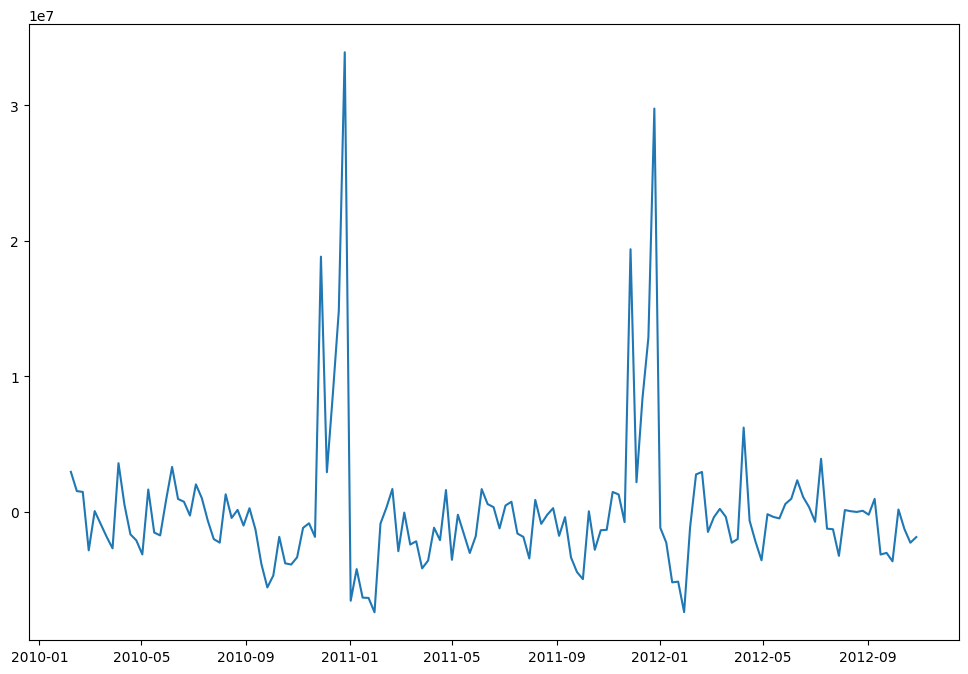

In [325]:
import scipy.signal

#Use a detrending technique to show the data without a trend

detrend = scipy.signal.detrend(weekly_sales.Weekly_Sales)

fig, ax=plt.subplots(figsize=(12,8))
ax.plot(weekly_sales.index, detrend)
plt.show()

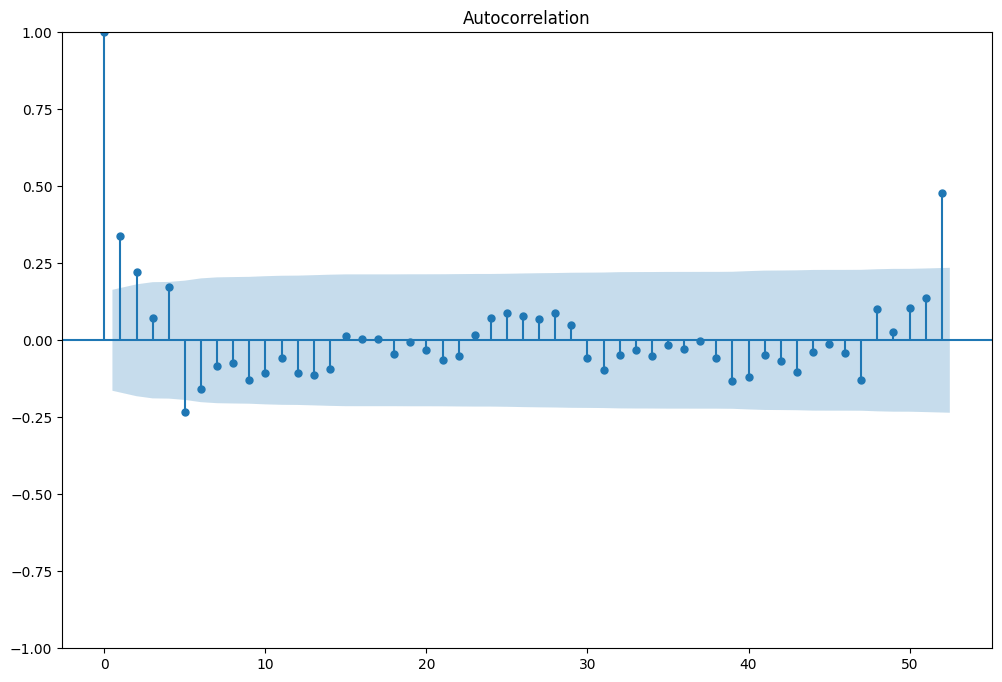

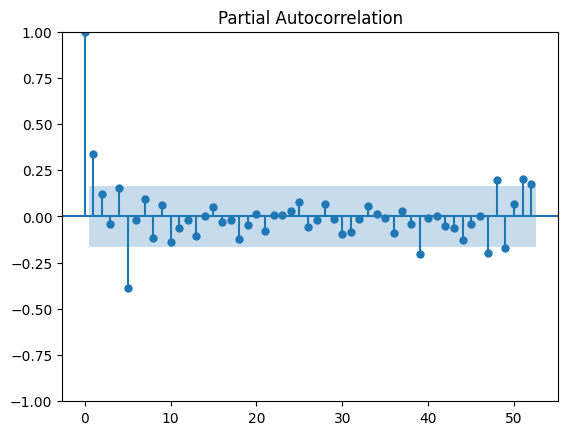

In [326]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

#Explore the autocorrelation and partial autocorrelation of the data up to 52 lags

fig, ax = plt.subplots(figsize=(12, 8))
plot_acf(weekly_sales.resample('w').sum().Weekly_Sales, lags=52, ax=ax) 
plt.show()

plot_pacf(weekly_sales.Weekly_Sales, lags=52) 
plt.show()

In [327]:
weekly_sales = weekly_sales[:-1]
weekly_sales.tail(5)

,Store,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Dept,Weekly_Sales,Size
Date,,,,,,,,,
2012-09-23,65781,199423.48,11571.788,520053.409020,21381.352,0,131040.0,44354547.11,403616471
2012-09-30,65866,201865.51,11428.121,521073.972005,21402.982,0,130785.0,43734899.40,402858901
2012-10-07,66296,194799.47,11452.944,523770.802422,20659.811,0,132468.0,47566639.31,405732233
2012-10-14,66453,172484.98,11653.301,526610.121540,20788.519,0,133371.0,46128514.25,407324080
2012-10-21,65630,177450.63,11441.317,520071.722546,20499.338,0,130255.0,45122410.57,400883123


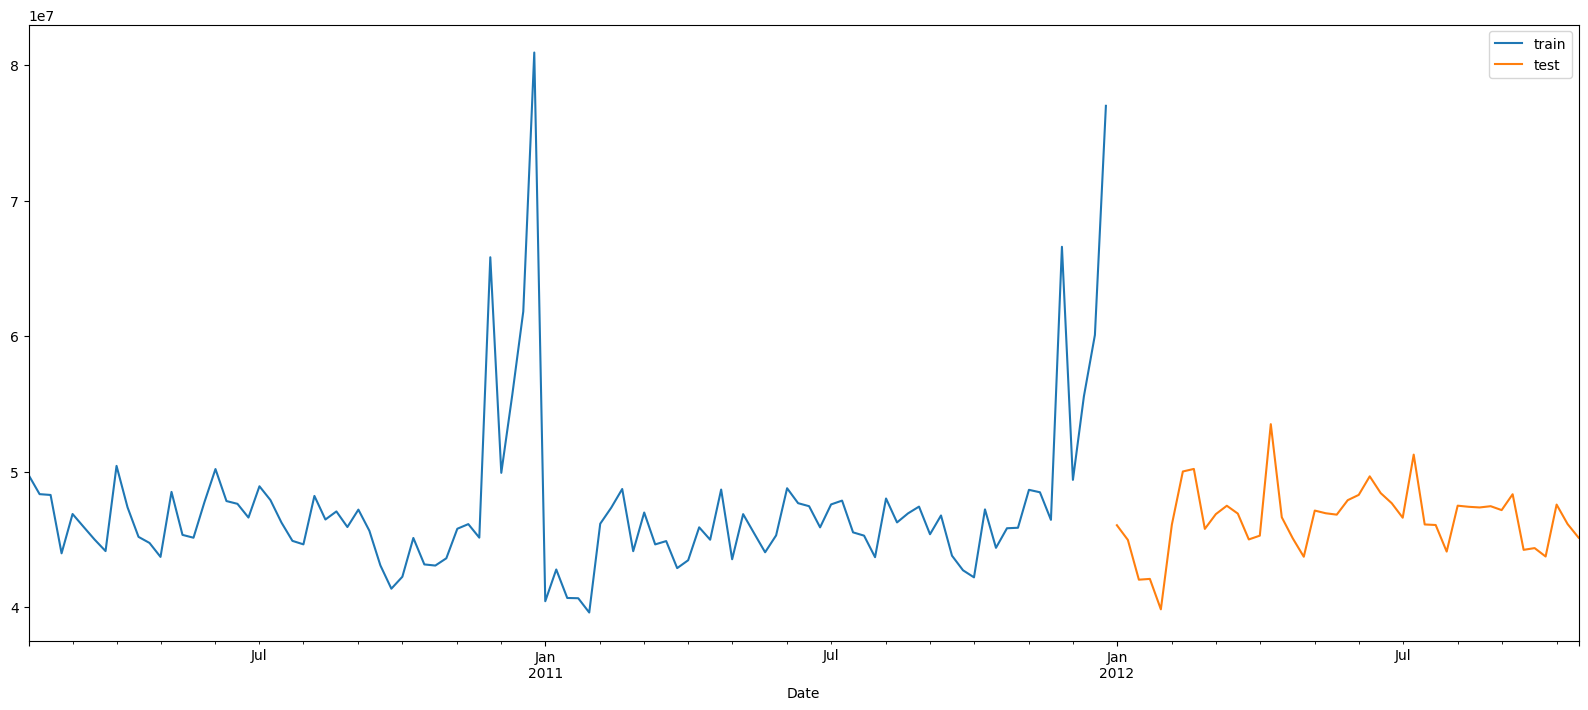

In [328]:
train = weekly_sales.loc['2010':'2011']
test = weekly_sales.loc['2012']
fig, ax = plt.subplots(figsize=(20,8))
train.Weekly_Sales.plot(ax=ax,label='train')
test.Weekly_Sales.plot(ax=ax,label='test')
plt.legend()
plt.show()

In [329]:
#Null Hypothesis- The data is not stationary
#Alternate Hypothesis- The data is stationary

result = adfuller(weekly_sales.Weekly_Sales)
print('p-value: ' +str(result[1]))

#The p-value is less than 0.05, so the null hypothesis can be rejected and conclude the data is stationary.

p-value: 2.956720799096608e-07


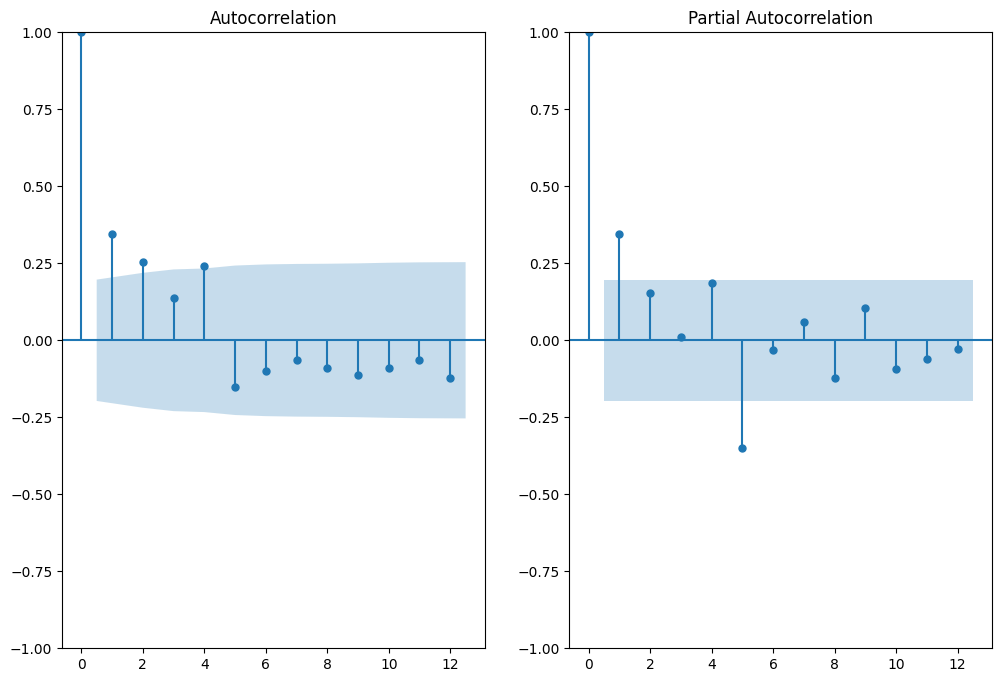

In [330]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

plot_acf(train.Weekly_Sales.dropna(), lags=12, ax=ax[0])
plot_pacf(train.Weekly_Sales.dropna(), lags=12, ax=ax[1])

plt.show()

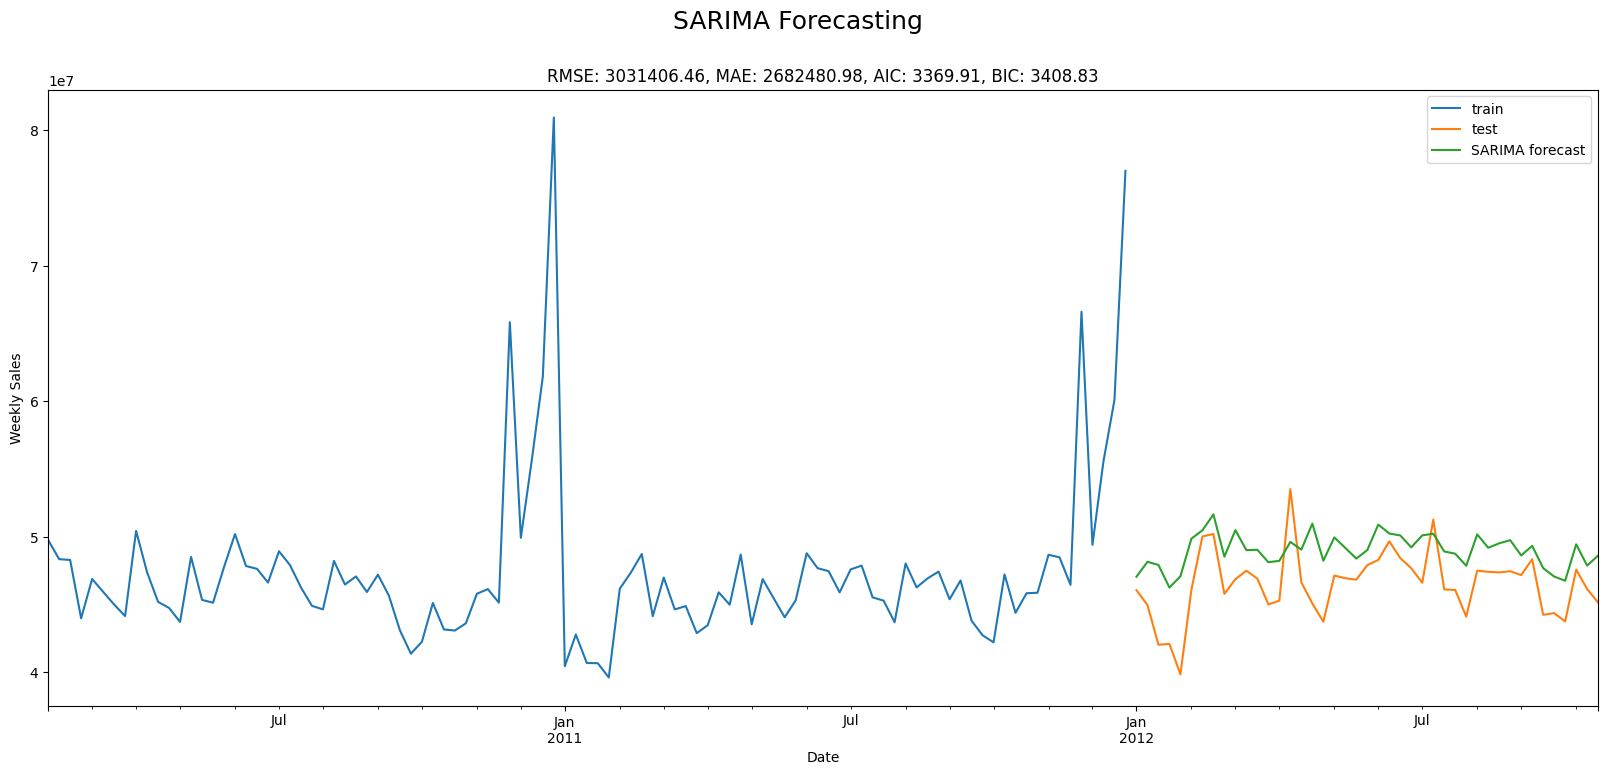

In [331]:
# create SARIMA model with best order and best seasonal_order
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(train.Weekly_Sales,order=(3,0,4),seasonal_order=(3,0,4,52)).fit()
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_sarima=test.copy() # create test set for this example

# To use this function for prediction you need to provide the first and last date
test_sarima['predicted']=sarima.predict(start=test_sarima.index[0],end=test_sarima.index[-1]) 

# calculate errors and round to 2 d.p
rmse_sarima=round(np.sqrt(mean_squared_error(test_sarima.Weekly_Sales,test_sarima.predicted)),2)
mae_sarima=round(mean_absolute_error(test_sarima.Weekly_Sales,test_sarima.predicted),2)
aic_sarima=round(sarima.aic,2)
bic_sarima=round(sarima.bic,2)

fig, ax = plt.subplots(figsize=(20,8))
train.Weekly_Sales.plot(ax=ax,label='train')
test_sarima.Weekly_Sales.plot(ax=ax,label='test')
test_sarima.predicted.plot(ax=ax,label='SARIMA forecast')
plt.legend()
plt.title('RMSE: '+str(rmse_sarima)+', MAE: '+str(mae_sarima)+', AIC: '+str(aic_sarima)+', BIC: '+str(bic_sarima))
plt.suptitle("SARIMA Forecasting",fontsize=18)
plt.ylabel('Weekly Sales')
plt.show()

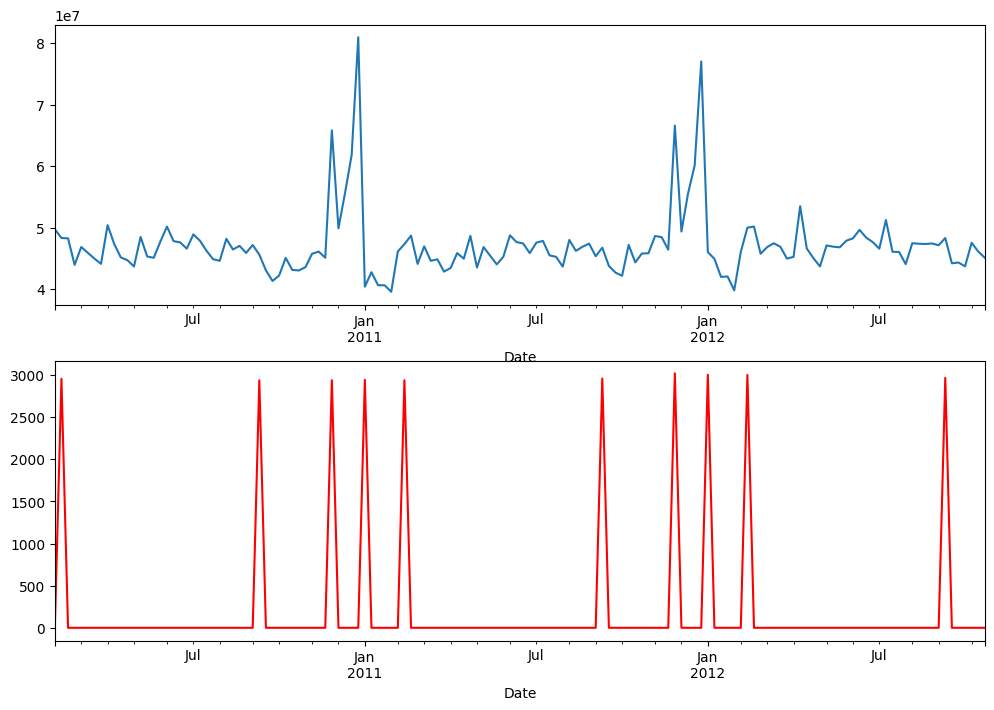

In [332]:
fig, ax = plt.subplots(nrows=2,figsize=(12,8))
weekly_sales.Weekly_Sales.plot(ax=ax[0])
weekly_sales.IsHoliday.plot(ax=ax[1],color='red')
plt.show()

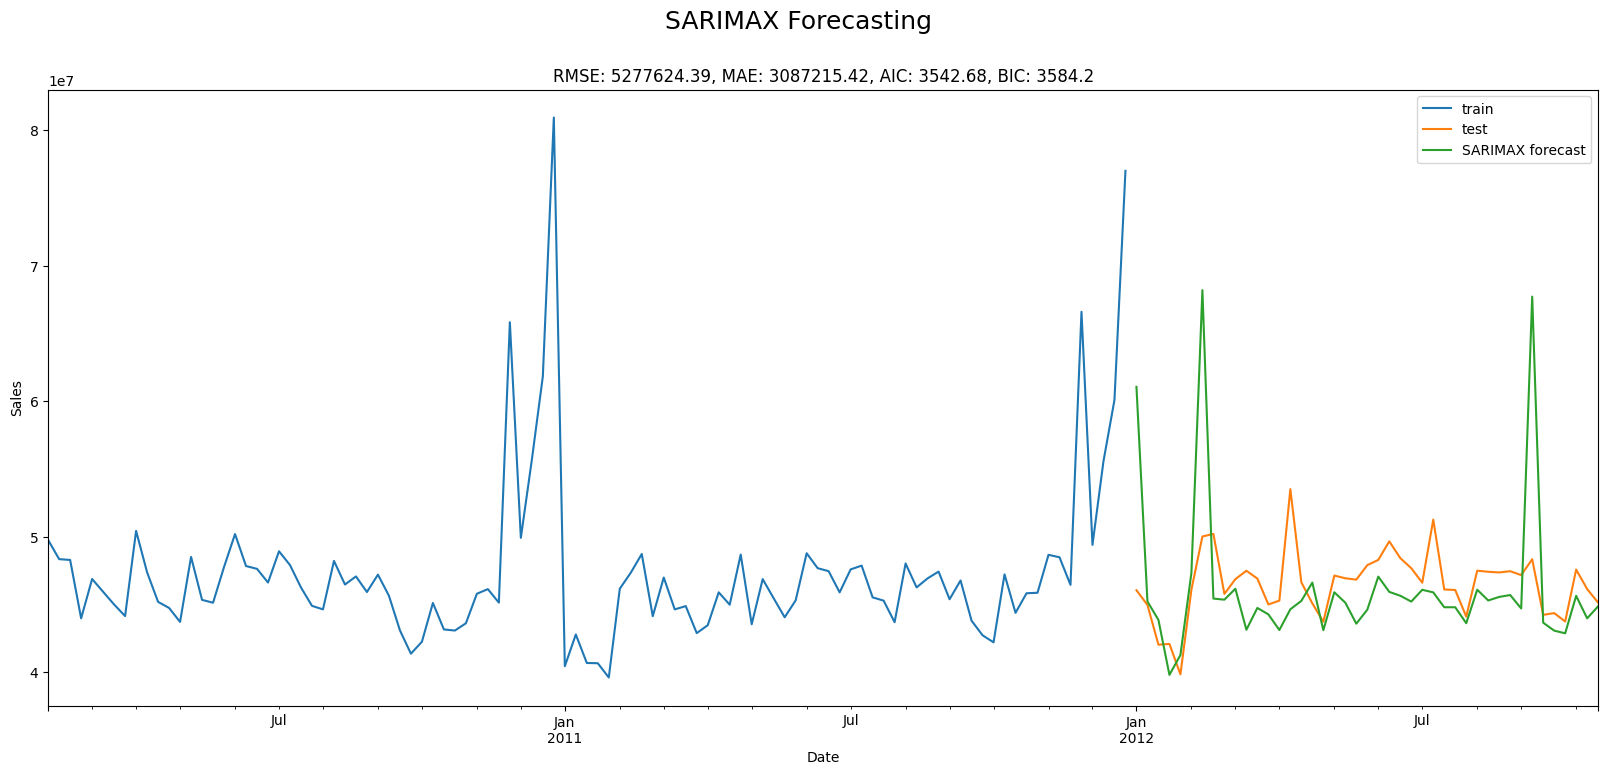

In [333]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMAX model (with exogenous variable: IsHoliday)
sarimax = SARIMAX(
    train.Weekly_Sales,
    exog=train.IsHoliday,
    order=(3,0,4),
    seasonal_order=(3,0,4,52)
).fit()

test_sarimax = test.copy()  # create test set for this example

# Predict using SARIMAX model, provide exog for test set
test_sarimax['predicted'] = sarimax.predict(
    start=test_sarimax.index[0],
    end=test_sarimax.index[-1],
    exog=test_sarimax.IsHoliday
)

# Calculate errors and round to 2 decimals
rmse_sarimax = round(np.sqrt(mean_squared_error(test_sarimax.Weekly_Sales, test_sarimax['predicted'])), 2)
mae_sarimax = round(mean_absolute_error(test_sarimax.Weekly_Sales, test_sarimax['predicted']), 2)
aic_sarimax = round(sarimax.aic, 2)
bic_sarimax = round(sarimax.bic, 2)

fig, ax = plt.subplots(figsize=(20,8))
train.Weekly_Sales.plot(ax=ax, label='train')
test_sarimax.Weekly_Sales.plot(ax=ax, label='test')
test_sarimax.predicted.plot(ax=ax, label='SARIMAX forecast')
plt.legend()
plt.title('RMSE: '+str(rmse_sarimax)+', MAE: '+str(mae_sarimax)+', AIC: '+str(aic_sarimax)+', BIC: '+str(bic_sarimax))
plt.suptitle("SARIMAX Forecasting", fontsize=18)
plt.ylabel('Sales')
plt.show()